In [ ]:

# 1. INSTALL DEPENDENCIES

!pip install tensorflow opencv-python scikit-learn tqdm facenet-pytorch albumentations

import os, cv2, random, shutil
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import (
    TimeDistributed, GlobalAveragePooling2D,
    Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive
drive.mount('/content/drive')




INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.6 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE     = 224
SEQ_LENGTH   = 20
BATCH_SIZE   = 4
EPOCHS       = 20
SEED         = 42


REAL_FOLDERS = [
    "/content/drive/MyDrive/Celeb Df/mini project/Celeb-real",
    "/content/drive/MyDrive/Celeb Df/mini project/YouTube-real",
]
FAKE_FOLDER  = "/content/drive/MyDrive/Celeb Df/mini project/Celeb-synthesis"

# ── Subset size — 150 real + 150 fake = 300 total ──
MAX_REAL = 136
MAX_FAKE = 111

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
# 3. TRACKING — run once per session before any training

best_auc_so_far = 0.0    # no previous result for Celeb-DF yet
best_run_number = 0
CURRENT_RUN     = 1      # ← increment each new run
print(f"Tracking initialized — starting fresh for Celeb-DF")


Tracking initialized — starting fresh for Celeb-DF


In [ ]:

# 4. FACE DETECTION

from facenet_pytorch import MTCNN
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn  = MTCNN(image_size=IMG_SIZE, margin=40, keep_all=False, device=device)

def detect_and_crop_face(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    from PIL import Image
    pil_img   = Image.fromarray(frame_rgb)
    boxes, _  = mtcnn.detect(pil_img)
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = [int(v) for v in boxes[0]]
        h, w   = frame_bgr.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        face   = frame_bgr[y1:y2, x1:x2]
        if face.size == 0:
            return cv2.resize(frame_bgr, (IMG_SIZE, IMG_SIZE))
        return cv2.resize(face, (IMG_SIZE, IMG_SIZE))
    h, w = frame_bgr.shape[:2]
    side = min(h, w)
    y0   = (h - side) // 2
    x0   = (w - side) // 2
    return cv2.resize(frame_bgr[y0:y0+side, x0:x0+side], (IMG_SIZE, IMG_SIZE))

In [ ]:
# 5. COLLECT VIDEO PATHS — subset selection happens here

def collect_videos(folders, max_count):
    """
    Collects up to max_count video paths from one or more folders.
    Randomly samples if more videos exist than max_count.
    """
    all_videos = []
    for folder in folders:
        if not os.path.exists(folder):
            print(f"Warning: folder not found — {folder}")
            continue
        for f in os.listdir(folder):
            if f.lower().endswith((".mp4", ".avi", ".mov")):
                all_videos.append(os.path.join(folder, f))

    random.shuffle(all_videos)
    selected = all_videos[:max_count]
    print(f"Selected {len(selected)} videos from {[os.path.basename(f) for f in folders]}")
    return selected

real_videos = collect_videos(REAL_FOLDERS, MAX_REAL)
fake_videos = collect_videos([FAKE_FOLDER], MAX_FAKE)

print(f"\nTotal real: {len(real_videos)}")
print(f"Total fake: {len(fake_videos)}")
print(f"Total dataset: {len(real_videos) + len(fake_videos)} videos")

Selected 0 videos from ['Celeb-real', 'YouTube-real']
Selected 0 videos from ['Celeb-synthesis']

Total real: 0
Total fake: 0
Total dataset: 0 videos


In [ ]:
# 6. FRAME EXTRACTION

def extract_frames(video_path, output_folder, sample_every=3):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    count, saved = 0, 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if count % sample_every == 0:
            face = detect_and_crop_face(frame)
            cv2.imwrite(os.path.join(output_folder, f"frame_{saved:04d}.jpg"), face)
            saved += 1
        count += 1
    cap.release()
    return saved

# Ensure base directories exist
os.makedirs("/content/frames/real", exist_ok=True)
os.makedirs("/content/frames/fake", exist_ok=True)

# Extract real videos
print("\nExtracting real videos...")
for video_path in tqdm(real_videos):
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    out_dir    = f"/content/frames/real/{video_name}"
    if not os.path.exists(out_dir):   # skip if already extracted
        extract_frames(video_path, out_dir)

# Extract fake videos
print("\nExtracting fake videos...")
for video_path in tqdm(fake_videos):
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    out_dir    = f"/content/frames/fake/{video_name}"
    if not os.path.exists(out_dir):
        extract_frames(video_path, out_dir)


Extracting real videos...


0it [00:00, ?it/s]



Extracting fake videos...


0it [00:00, ?it/s]


In [ ]:
# 7. AUGMENTATION

import albumentations as A

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.6),
    A.GaussNoise(var_limit=(10, 40), p=0.4),
    A.RandomGamma(p=0.4),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.08, rotate_limit=8, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),
])

def load_sequence(frames_path, augment=False):
    all_frames = sorted([f for f in os.listdir(frames_path) if f.endswith('.jpg')])
    if len(all_frames) >= SEQ_LENGTH:
        idxs     = np.linspace(0, len(all_frames) - 1, SEQ_LENGTH, dtype=int)
        selected = [all_frames[i] for i in idxs]
    else:
        selected = all_frames
    seq = []
    for f in selected:
        img = cv2.imread(os.path.join(frames_path, f))
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if augment:
            img = train_aug(image=img)['image']
        seq.append(img.astype(np.float32) / 255.0)
    while len(seq) < SEQ_LENGTH:
        seq.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32))
    return np.array(seq, dtype=np.float32)


/tmp/ipykernel_1371/2368940090.py:8: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 40), p=0.4),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1371/2368940090.py:12: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),


In [ ]:
# 8. BUILD DATASET ARRAYS

X_list, y_list = [], []

for label, cls in [("real", 0), ("fake", 1)]:
    base = f"/content/frames/{label}"
    folders = [f for f in os.listdir(base) if os.path.isdir(os.path.join(base, f))]
    print(f"Loading {len(folders)} {label} sequences...")
    for vid_folder in tqdm(folders):
        fpath = os.path.join(base, vid_folder)
        seq   = load_sequence(fpath, augment=False)
        X_list.append(seq)
        y_list.append(cls)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print(f"\nDataset shape : Xx={X.shape}, yy={y.shape}")
print(f"Class dist    : real={np.sum(y==0)}, fake={np.sum(y==1)}")

# Save to Drive  never need to re-extract frames
np.save("/content/drive/MyDrive/Celeb Df/mini project/Xx_celebdf.npy", X)
np.save("/content/drive/MyDrive/Celeb Df/mini project/yy_celebdf.npy", y)
print("Arrays saved to Drive!")

Loading 136 real sequences...


100%|██████████| 136/136 [00:01<00:00, 70.27it/s]


Loading 111 fake sequences...


100%|██████████| 111/111 [00:01<00:00, 64.42it/s]



Dataset shape : Xx=(247, 20, 224, 224, 3), yy=(247,)
Class dist    : real=136, fake=111
Arrays saved to Drive!


In [ ]:
# 9. LOAD PREPROCESSED DATA

X = np.load("/content/drive/MyDrive/CELEB DF /mini project/Xx_celebdf.npy")
y = np.load("/content/drive/MyDrive/CELEB DF /yy_celebdf (1).npy")

In [ ]:
print(f"Before balancing: real={np.sum(y==0)}, fake={np.sum(y==1)}")

# ── Balance dataset without re-extracting frames ──
real_idx = np.where(y == 0)[0]
fake_idx = np.where(y == 1)[0]


np.random.seed(SEED)
real_idx_balanced = np.random.choice(real_idx, size=len(fake_idx), replace=False)


balanced_idx = np.concatenate([real_idx_balanced, fake_idx])
np.random.shuffle(balanced_idx)

X = X[balanced_idx]
y = y[balanced_idx]

print(f"After balancing : real={np.sum(y==0)}, fake={np.sum(y==1)}")
print(f"Total videos    : {len(y)}")

Before balancing: real=136, fake=111
After balancing : real=111, fake=111
Total videos    : 222


In [ ]:
# 10. TRAIN / VAL / TEST SPLIT

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"Train dist : {np.bincount(y_train)}")
print(f"Val dist   : {np.bincount(y_val)}")

class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f"Class weights: {class_weights}")

Train : (133, 20, 224, 224, 3) | Val : (44, 20, 224, 224, 3) | Test : (45, 20, 224, 224, 3)
Train dist : [66 67]
Val dist   : [22 22]
Class weights: {0: np.float64(1.0075757575757576), 1: np.float64(0.9925373134328358)}


In [ ]:
# 11. DATA GENERATOR

class DeepfakeGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size, augment=False, shuffle=True):
        super().__init__()
        self.X       = X
        self.y       = y
        self.bs      = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.bs))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.bs:(idx + 1) * self.bs]
        Xb = self.X[batch_idx].copy()
        yb = self.y[batch_idx]
        if self.augment:
            for i in range(len(Xb)):
                aug_seq = []
                for t in range(SEQ_LENGTH):
                    frame = (Xb[i, t] * 255).astype(np.uint8)
                    frame = train_aug(image=frame)['image']
                    aug_seq.append(frame.astype(np.float32) / 255.0)
                Xb[i] = np.array(aug_seq)
        return Xb, yb

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = DeepfakeGenerator(X_train, y_train, BATCH_SIZE, augment=True,  shuffle=True)
val_gen   = DeepfakeGenerator(X_val,   y_val,   BATCH_SIZE, augment=False, shuffle=False)

NameError: name 'X_train' is not defined

In [ ]:
# 12. MODEL

from tensorflow.keras.regularizers import l2

def build_model(seq_length=SEQ_LENGTH, img_size=IMG_SIZE, lstm_units=128):
    cnn_base = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    # With 200 videos unfreeze last 20 layers — more data than UADFV allows more fine-tuning
    for layer in cnn_base.layers[:-20]:
        layer.trainable = False
    for layer in cnn_base.layers[-20:]:
        layer.trainable = True

    inp = Input(shape=(seq_length, img_size, img_size, 3), name='video_input')
    x   = TimeDistributed(cnn_base, name='xception')(inp)
    x   = TimeDistributed(GlobalAveragePooling2D(), name='gap')(x)

    x = Bidirectional(
        LSTM(lstm_units, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
        name='bilstm'
    )(x)
    x = LSTM(64, dropout=0.3, recurrent_dropout=0.2, name='lstm')(x)

    x   = BatchNormalization()(x)
    x   = Dense(64, activation='relu', kernel_regularizer=l2(1e-3))(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.6)(x)
    out = Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    return Model(inputs=inp, outputs=out)

model = build_model()
model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 20, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (TimeDistributed)      │ (None, 20, 7, 7, 2048) │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (TimeDistributed)           │ (None, 20, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 20, 256)        │     2,229,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,177,641 (88.42 MB)

 Trainable params: 9,642,281 (36.78 MB)

 Non-trainable params: 13,535,360 (51.63 MB)

In [ ]:
# 13. COMPILE

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

In [ ]:
# 14.

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=9,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        "/content/deepfake_current_best.keras",
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
]


In [ ]:
# 15. TRAIN

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.4468 - auc: 0.4213 - loss: 1.2302 - precision: 0.4788 - recall: 0.4643
Epoch 1: val_auc improved from None to 0.77789, saving model to /content/deepfake_current_best.keras

Epoch 1: finished saving model to /content/deepfake_current_best.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.5639 - auc: 0.5581 - loss: 1.1022 - precision: 0.5672 - recall: 0.5672 - val_accuracy: 0.6136 - val_auc: 0.7779 - val_loss: 0.7452 - val_precision: 0.6000 - val_recall: 0.6818 - learning_rate: 1.0000e-04
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.6058 - auc: 0.6074 - loss: 1.0897 - precision: 0.5779 - recall: 0.6126
Epoch 2: val_auc improved from 0.77789 to 0.78099, saving model to /content/deepfake_current_best.keras

Epoch 2: finished saving model to /content/deepfake_current_best.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5714 - auc: 0.5499 - loss: 1.0843 - precision: 0.5833 - recall: 0.

In [ ]:
import os

# Create the target directory
os.makedirs("/content/drive/MyDrive/Celeb Df/mini project", exist_ok=True)

# Save to Drive
current_model.save(
    "/content/drive/MyDrive/Celeb Df/mini project/deepfake_celebdf_final.keras"
)
print("Model saved to Drive!")

# Also save X_test and y_test
np.save("/content/drive/MyDrive/Celeb Df/mini project/X_test.npy", X_test)
np.save("/content/drive/MyDrive/Celeb Df/mini project/y_test.npy",  y_test)
np.save("/content/drive/MyDrive/Celeb Df/mini project/X_val.npy",  X_val)
np.save("/content/drive/MyDrive/Celeb Df/mini project/y_val.npy",  y_val)
print("Test and val splits saved to Drive!")

Model saved to Drive!
Test and val splits saved to Drive!


In [ ]:
from tensorflow.keras.models import load_model

model  = load_model("/content/drive/MyDrive/Celeb Df/mini project/deepfake_celebdf_final.keras")
X_test = np.load("/content/drive/MyDrive/Celeb Df/mini project/X_test.npy")
y_test = np.load("/content/drive/MyDrive/Celeb Df/mini project/y_test.npy")
X_val  = np.load("/content/drive/MyDrive/Celeb Df/mini project/X_val.npy")
y_val  = np.load("/content/drive/MyDrive/Celeb Df/mini project/y_val.npy")



In [ ]:
from tensorflow.keras.models import load_model

# Load best model from Google Drive
current_model = load_model("/content/drive/MyDrive/Celeb Df/mini project/deepfake_celebdf_final.keras")
print("Best model loaded!")

In [ ]:
#Evaluation best threshold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

val_probs  = current_model.predict(X_val,  batch_size=BATCH_SIZE).flatten()
test_probs = current_model.predict(X_test, batch_size=BATCH_SIZE).flatten()

print("── Threshold search on Val set ──────────────")
best_threshold = 0.5
best_val_f1    = 0.0

for threshold in np.arange(0.1, 0.9, 0.05):
    preds = (val_probs > threshold).astype(int)
    f1    = f1_score(y_val, preds, zero_division=0)
    acc   = accuracy_score(y_val, preds)
    if f1 > best_val_f1:
        best_val_f1    = f1
        best_threshold = threshold
    print(f"Threshold {threshold:.2f} → Val Acc: {acc:.4f}  Val F1: {f1:.4f}")

print(f"\nBest threshold : {best_threshold:.2f}")
print(f"Best val F1    : {best_val_f1:.4f}")

print("\n── Test Results at best threshold ───────────")
test_preds    = (test_probs > best_threshold).astype(int)
test_preds_05 = (test_probs > 0.5).astype(int)
test_acc      = accuracy_score(y_test, test_preds)
test_f1       = f1_score(y_test, test_preds)
test_auc      = roc_auc_score(y_test, test_probs)

print(f"\n{classification_report(y_test, test_preds, target_names=['Real','Fake'])}")

print("── Full Comparison ──────────────────────────────")
print(f"{'Metric':<15} {'Val':>10} {'Test@0.5':>10} {'Test@best':>10}")
print("-" * 48)
print(f"{'Accuracy':<15} {accuracy_score(y_val, (val_probs>0.5).astype(int)):>10.4f} {accuracy_score(y_test, test_preds_05):>10.4f} {test_acc:>10.4f}")
print(f"{'F1 Score':<15} {f1_score(y_val, (val_probs>0.5).astype(int)):>10.4f} {f1_score(y_test, test_preds_05):>10.4f} {test_f1:>10.4f}")
print(f"{'AUC':<15} {roc_auc_score(y_val, val_probs):>10.4f} {test_auc:>10.4f} {test_auc:>10.4f}")
print(f"{'Threshold':<15} {'0.50':>10} {'0.50':>10} {best_threshold:>10.2f}")



11/11 ━━━━━━━━━━━━━━━━━━━━ 32s 545ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 521ms/step
── Threshold search on Val set ──────────────
Threshold 0.10 → Val Acc: 0.8409  Val F1: 0.8571
Threshold 0.15 → Val Acc: 0.8864  Val F1: 0.8936
Threshold 0.20 → Val Acc: 0.8636  Val F1: 0.8696
Threshold 0.25 → Val Acc: 0.8864  Val F1: 0.8889
Threshold 0.30 → Val Acc: 0.8864  Val F1: 0.8837
Threshold 0.35 → Val Acc: 0.8636  Val F1: 0.8571
Threshold 0.40 → Val Acc: 0.8864  Val F1: 0.8780
Threshold 0.45 → Val Acc: 0.8636  Val F1: 0.8500
Threshold 0.50 → Val Acc: 0.8409  Val F1: 0.8205
Threshold 0.55 → Val Acc: 0.8182  Val F1: 0.7895
Threshold 0.60 → Val Acc: 0.8182  Val F1: 0.7778
Threshold 0.65 → Val Acc: 0.7273  Val F1: 0.6250
Threshold 0.70 → Val Acc: 0.7273  Val F1: 0.6250
Threshold 0.75 → Val Acc: 0.6818  Val F1: 0.5333
Threshold 0.80 → Val Acc: 0.5909  Val F1: 0.3077
Threshold 0.85 → Val Acc: 0.5000  Val F1: 0.0000

Best threshold : 0.15
Best val F1    : 0.8936

── Test Results at best threshold ─────

In [ ]:
import numpy as np

probs = model.predict(X_test)
preds = (probs > 0.65).astype(int)

correct = (preds == y_test)

# confidence = max(prob, 1-prob)
confidence = np.maximum(probs, 1 - probs)

# sort by confidence
for c, corr in zip(confidence[:20], correct[:20]):
    print(f"Confidence: {c.item():.2f}, Correct: {corr}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 54s 24s/step
Confidence: 0.91, Correct: [ True False  True  True False  True False  True  True False  True  True
 False False False False  True  True False False False  True False False
 False  True False  True False  True  True  True False  True False False
  True  True False False  True False  True  True  True]
Confidence: 0.67, Correct: [False  True False False  True False  True False False  True False False
  True  True  True  True False False  True  True  True False  True  True
  True False  True False  True False False False  True False  True  True
 False False  True  True False  True False False False]
Confidence: 0.91, Correct: [ True False  True  True False  True False  True  True False  True  True
 False False False False  True  True False False False  True False False
 False  True False  True False  True  True  True False  True False False
  True  True False False  True False  True  True  True]
Confidence: 0.92, Correct: [ True False  True  True Fals

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step


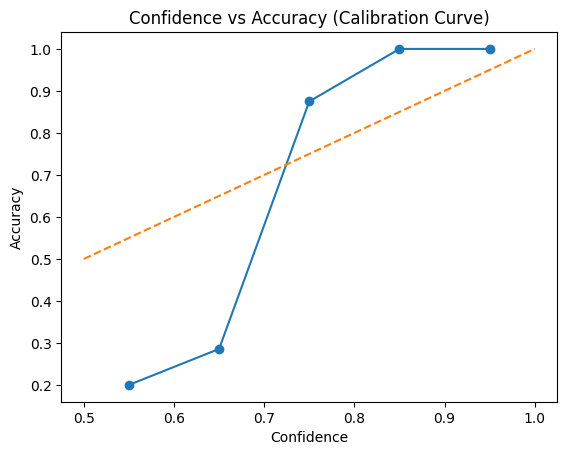

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# predictions
probs = model.predict(X_test).flatten()
preds = (probs > 0.65).astype(int)

# correctness (1 = correct, 0 = wrong)
correct = (preds == y_test).astype(int)

# confidence
confidence = np.maximum(probs, 1 - probs)

# create bins
bins = np.linspace(0.5, 1.0, 6)
bin_centers = []
bin_accuracy = []

for i in range(len(bins)-1):
    mask = (confidence >= bins[i]) & (confidence < bins[i+1])

    if np.sum(mask) > 0:
        acc = np.mean(correct[mask])
        bin_accuracy.append(acc)
        bin_centers.append((bins[i] + bins[i+1]) / 2)

# plot
plt.figure()
plt.plot(bin_centers, bin_accuracy, marker='o')
plt.plot([0.5, 1.0], [0.5, 1.0], linestyle='--')  # perfect calibration line

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Confidence vs Accuracy (Calibration Curve)")
plt.show()

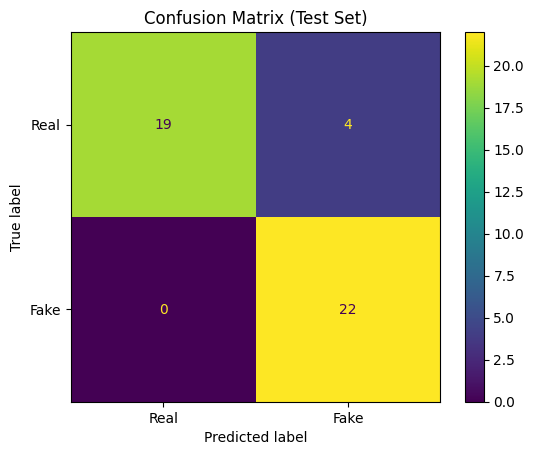

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use best threshold
threshold = 0.15
y_pred = (probs >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot()

plt.title("Confusion Matrix (Test Set)")
plt.show()

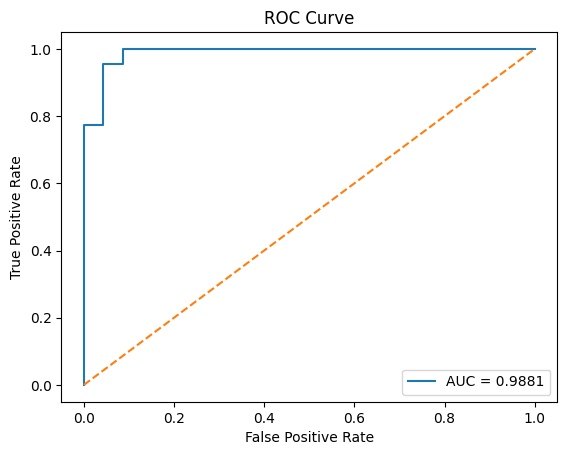

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# 18. MAJORITY VOTING PREDICTION

def predict_video_majority(video_path, n_clips=5, verbose=True):
    cap          = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    clip_preds = []
    for clip_idx in range(n_clips):
        start = int((clip_idx / n_clips) * total_frames)
        cap   = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start)
        frames = []
        while len(frames) < SEQ_LENGTH:
            ret, frame = cap.read()
            if not ret:
                break
            face = detect_and_crop_face(frame)
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            frames.append(face.astype(np.float32) / 255.0)
        cap.release()
        while len(frames) < SEQ_LENGTH:
            frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32))
        seq  = np.expand_dims(np.array(frames[:SEQ_LENGTH]), axis=0)
        prob = current_model.predict(seq, verbose=0)[0][0]
        clip_preds.append(prob)
    avg_prob = np.mean(clip_preds)
    result   = "Fake" if avg_prob > 0.5 else "Real"
    if verbose:
        print(f"Clip probabilities: {[f'{p:.3f}' for p in clip_preds]}")
        print(f"Average: {avg_prob:.3f} → {result}")
    return result, avg_prob

In [ ]:

import cv2
#  test on a fake video from Drive
result, confidence = predict_video_majority(
    "/content/id10_id7_0001.mp4",
    n_clips=5,
    verbose=True
)
print(f"\nFinal verdict : {result}")
print(f"Confidence    : {confidence:.3f}")

Clip probabilities: ['0.596', '0.668', '0.593', '0.611', '0.616']
Average: 0.617 → Fake

Final verdict : Fake
Confidence    : 0.617


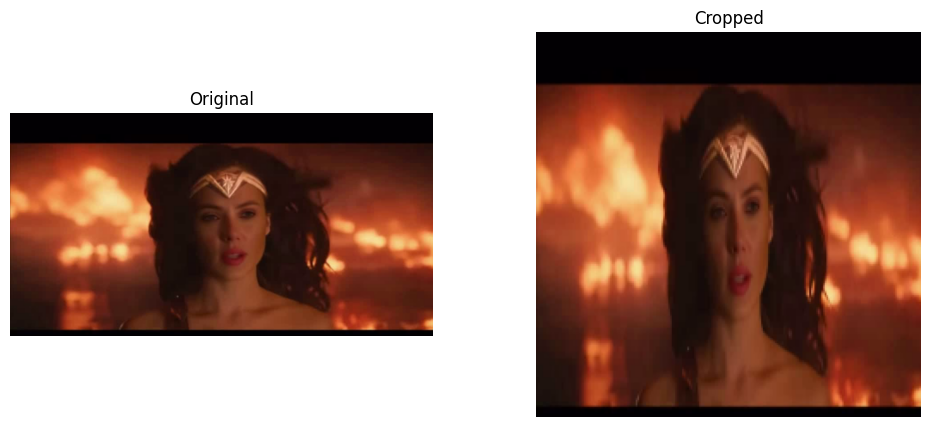

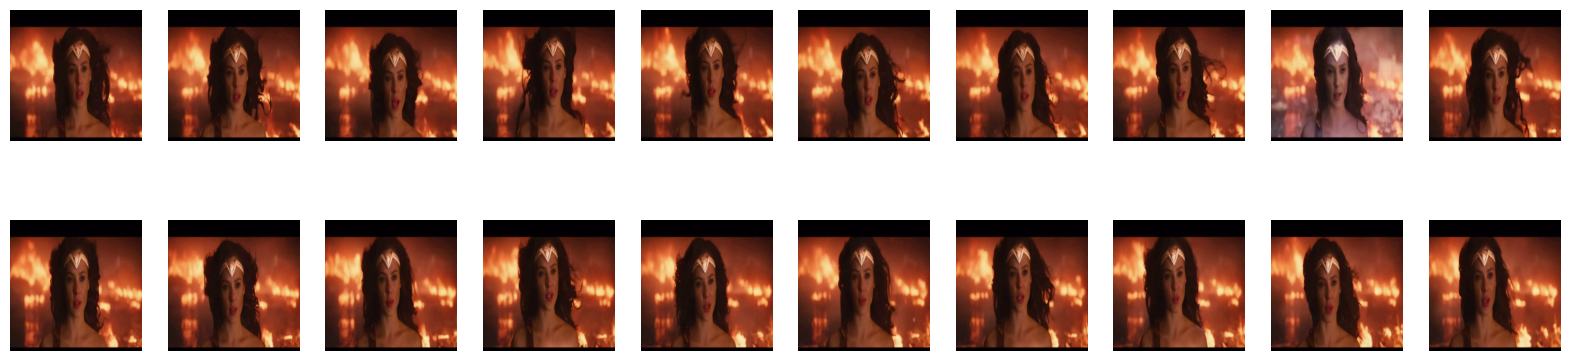

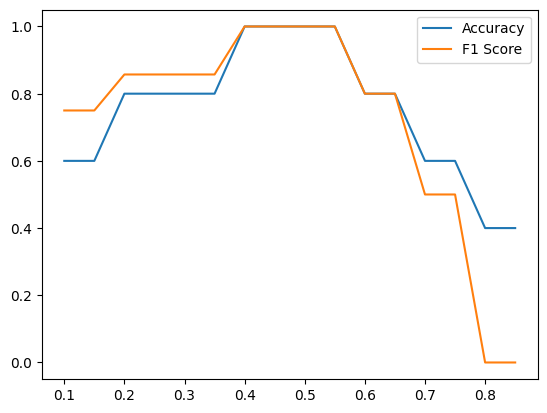

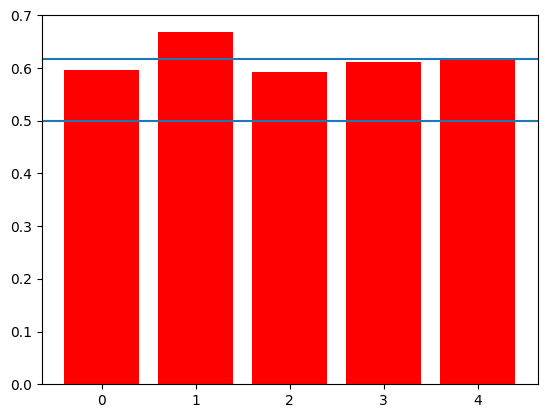

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2
from sklearn.metrics import accuracy_score, f1_score

#  Dummy face detection
def detect_and_crop_face(frame):
    return cv2.resize(frame, (224, 224))

# ---------------- PREPROCESSING ----------------


def show_preprocessing_result(video_path, save_path="preprocessing_result.png"):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if not ret or frame is None:
        print("Error: Cannot read video")
        return

    original = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    cropped  = detect_and_crop_face(frame)
    cropped  = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(original)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(cropped)
    axes[1].set_title('Cropped')
    axes[1].axis('off')

    plt.show()


def show_frame_sequence(video_path):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = np.linspace(0, total-1, 20, dtype=int)

    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if ret:
            face = detect_and_crop_face(frame)
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            frames.append(face)
    cap.release()

    fig, axes = plt.subplots(2, 10, figsize=(20, 5))
    for i, ax in enumerate(axes.flatten()):
        if i < len(frames):
            ax.imshow(frames[i])
        ax.axis('off')
    plt.show()


# ---------------- POSTPROCESSING ----------------

def show_threshold_search(val_probs, y_val):
    thresholds = np.arange(0.1, 0.9, 0.05)
    accs, f1s = [], []

    for t in thresholds:
        preds = (val_probs > t).astype(int)
        accs.append(accuracy_score(y_val, preds))
        f1s.append(f1_score(y_val, preds))

    plt.plot(thresholds, accs, label="Accuracy")
    plt.plot(thresholds, f1s, label="F1 Score")
    plt.legend()
    plt.show()


def show_majority_voting(clip_probs):
    avg_prob = np.mean(clip_probs)

    colors = ['red' if p > 0.5 else 'blue' for p in clip_probs]
    plt.bar(range(len(clip_probs)), clip_probs, color=colors)
    plt.axhline(y=0.5)
    plt.axhline(y=avg_prob)
    plt.show()



video_path = "/content/id10_id7_0001.mp4"

# Run preprocessing
show_preprocessing_result(video_path)
show_frame_sequence(video_path)

# Run postprocessing
val_probs = np.array([0.2, 0.7, 0.6, 0.4, 0.8])
y_val     = np.array([0,   1,   1,   0,   1])

show_threshold_search(val_probs, y_val)

clip_probs = [0.596, 0.668, 0.593, 0.611, 0.616]
show_majority_voting(clip_probs)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Run before prediction
#
from facenet_pytorch import MTCNN
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn  = MTCNN(image_size=IMG_SIZE, margin=40, keep_all=False, device=device)

def detect_and_crop_face(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    from PIL import Image
    pil_img   = Image.fromarray(frame_rgb)
    boxes, _  = mtcnn.detect(pil_img)
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = [int(v) for v in boxes[0]]
        h, w   = frame_bgr.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        face   = frame_bgr[y1:y2, x1:x2]
        if face.size == 0:
            return cv2.resize(frame_bgr, (IMG_SIZE, IMG_SIZE))
        return cv2.resize(face, (IMG_SIZE, IMG_SIZE))
    h, w = frame_bgr.shape[:2]
    side = min(h, w)
    y0   = (h - side) // 2
    x0   = (w - side) // 2
    return cv2.resize(frame_bgr[y0:y0+side, x0:x0+side], (IMG_SIZE, IMG_SIZE))

In [ ]:
# 19. PUSH TO DRIVE — uncomment only when satisfied
# ─────────────────────────────────────────────────────────────────────────────
# shutil.copy(
#     f"/content/deepfake_best_run{best_run_number}_auc{best_auc_so_far:.4f}.keras",
#     f"/content/drive/MyDrive/Celeb Df/mini project/deepfake_final_auc{best_auc_so_far:.4f}.keras"
# )
# print("Saved to Drive!")